In [24]:
import networkx as nx
import numpy as np
import random
import math
import powerlaw as pwl
from collections import Counter
from scipy.stats import pearsonr
from statistics import variance, mean
from sklearn.metrics import normalized_mutual_info_score as nmi

%pylab inline

Populating the interactive namespace from numpy and matplotlib


c:\ProgramData\Anaconda3\lib\site-packages\IPython\core\magics\pylab.py:159: UserWarning: pylab import has clobbered these variables: ['random', 'mean']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


Populating the interactive namespace from numpy and matplotlib
The graph has 18772 nodes and 198110 edges
The average degree is 21.107
d = 0.00112
The graph is connected? False
The graph is divided in 290 components.
Number of nodes in giant component =  17903


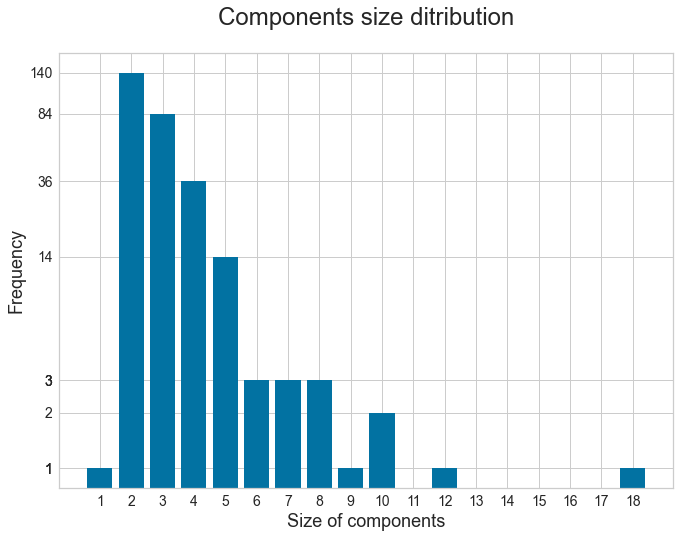

The giant component has 17903 nodes, 0.954 of total nodes.
The giant component has 197031 edges, 0.995 of total edges.


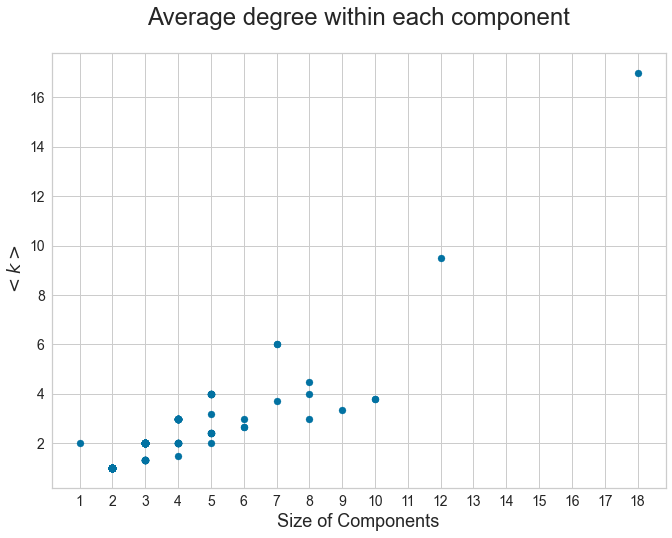

Pearson statistic = 0.909 
P value = 6.185e-111
d = 0.00123


In [25]:
%run -i project.ipynb

### Centrality measure

Further analysis is performed only on the giant component.

- #### Closeness centrality

In [11]:
%%time

closeness = []

for i in giant_component.nodes():

    closeness.append(nx.closeness_centrality(giant_component, i))

Wall time: 1h 57min 35s


In [12]:
# saving closeness centrality measure for each node in .txt file
f1 = open("closeness.txt", "w")
degree_gc = list(dict(giant_component.degree()).values())
i = 0

f1.write("# CLOSENESS CENTRALITY FOR EACH NODE\n")
f1.write("# node label        degree        closeness\n")

for node in giant_component.nodes():
    
    f1.write( str(node) + " " + str(degree_gc[i]) + " " + str(closeness[i]) + "\n")
    i += 1

f1.close()

- ##### Betweenness centrality

In [39]:
%%time

dict_betweenness = nx.betweenness_centrality(giant_component)

Wall time: 2h 42min 56s


In [44]:
# saving betweenness centrality measure for each node in .txt file
betweenness = [i for i in dict_betweenness.values()]
i = 0

f2 = open("betweenness.txt", "w")

f2.write("# BETWEENNESS CENTRALITY FOR EACH NODE\n")
f2.write("# node label        betweenness\n")

for node in giant_component.nodes():

    f2.write( str(node) + " " + str(betweenness[i]) + "\n" )
    i += 1

f2.close()

- #### Eigenvector centrality

In [26]:
%%time

eigenvec = nx.eigenvector_centrality(giant_component, max_iter=1000, tol= 1e-06)

Wall time: 10 s


In [27]:
file_eigen = open("eigenvector_centrality.txt", "w")

file_eigen.write('# EIGENVECTOR CENTRALITY FOR EACH NODE\n')
file_eigen.write('# node     eigenvector centrality\n')

for node, centr in eigenvec.items():

    file_eigen.write( str(node) + " " + str(centr) + '\n')

- #### Pagerank

In [28]:
%%time

pagerank = nx.pagerank(giant_component, 0.8)

Wall time: 1.53 s


In [29]:
file_pagerank = open("pagerank.txt", "w")

file_pagerank.write('# PAGERANK PER EACH NODE\n')
file_pagerank.write('# node pagerank\n')

for node, rank in pagerank.items():
    file_pagerank.write( str(node) + " " + str(rank) + '\n')

### Diameter & shortest path

Further analysis is performed only on the giant component.

- ##### Average shortest path

In [ ]:
%%time 

d_av = nx.average_shortest_path_length(giant_component)
print("Average shortest path lenght =", d_av)

- ##### Diameter

In [7]:
%%time

d_max = nx.diameter(giant_component)
print("Diameter =", d_max)

Diameter = 14
Wall time: 4h 20min 33s


In [13]:
# saving average shortest path and diameter measure in .txt file
f3 = open("path_analysis.txt", "w")

f3.write("# AVERAGE PATH LENGTH & DIAMETER\n")
f3.write("# average path length        diameter\n")
f3.write( "str(d_av)" + " " + str(d_max) + "\n" )

f3.close()

- Analysis of longest shortest path

In [5]:
%%time

longest_sp = []

for node in giant_component.nodes():
    longest_sp.append(
                      max(nx.shortest_path_length(giant_component, source=node).values())
                     )

Wall time: 1h 44min 17s


In [6]:
# loading results in a .txt file

np.savetxt('longest_shortest_path.txt', longest_sp)

### Clustering coefficient

- ##### Clustering coefficient for each node

In [17]:
%%time 

dict_clustering_coeff = nx.clustering(G)
dict_clustering_coeff_gc = nx.clustering(giant_component)

Wall time: 29.2 s


In [29]:
# WHOLE NETWORK
# saving clustering coefficient and clustering coeffincient for each node in .txt file
clustering_coeff = [i for i in dict_clustering_coeff.values()]
i = 0

f4 = open("clustering analysis.txt", "w")

f4.write("# CLUSTERING COEFFICIENT ANALYSIS\n")
f4.write("# node label        clustering coefficient\n")

for node in G.nodes():

    f4.write( str(node) + " " + str(clustering_coeff[i]) + "\n" )
    i += 1

f4.close()

In [30]:
# GIANT COMPONENT
# saving clustering coefficient and clustering coeffincient for each node in .txt file
clustering_coeff_gc = [i for i in dict_clustering_coeff_gc.values()]
i = 0

f5 = open("clustering analysis_gc.txt", "w")

f5.write("# CLUSTERING COEFFICIENT ANALYSIS\n")
f5.write("# node label        clustering coefficient\n")

for node in giant_component.nodes():

    f5.write( str(node) + " " + str(clustering_coeff_gc[i]) + "\n" )
    i += 1

f5.close()